<a href="https://colab.research.google.com/github/MacKumachin/Clifford-FBSM-SignalControl/blob/main/Fasuical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Table 1: Key Indicators: Takahashi Era ---


,Year,Bond_Dep_Ratio_Percent,Mil_Exp_Percent_GNP,WPI,State
0,1931,28.3,3.1,74.8,Depression
1,1933,36.5,5.6,96.8,Reflation
2,1935,29.8,7.4,100.2,Friction (IG↑)
3,1936,31.2,9.8,104.2,Collapse




--- Table 2: Key Indicators: Abenomics ---


,Year,Mon_Base_Tril,10Y_Yield_Percent,USD_JPY,State
0,2012,138,0.79,86.7,Pre-Regime
1,2013,202,0.74,105.3,Reflation
2,2016,437,0.04,117.0,YCC (Pinned)
3,2022,632,0.42,131.1,FX Breakout




--- Table 4: Sensitivity Analysis (Scenario S) ---


,Scenario,USD_JPY,Wedge_Size,System_State
0,Case A,100,None (0.0),Safe Baseline
1,Case B,140,Moderate (0.3),Friction
2,Case C,180,Huge (0.8),Singularity
3,Case D,200,Total (1.0),Collapse




--- Table 5: Granger Causality Test Results (Takahashi Era) ---


,Null_Hypothesis,F_Statistic,p_value,Conclusion
0,IG !-> WPI Volatility,4.82,0.012**,Reject
1,WPI Volatility !-> IG,1.15,0.320,Accept
2,IG !-> Delta USD/JPY,3.95,0.045*,Reject


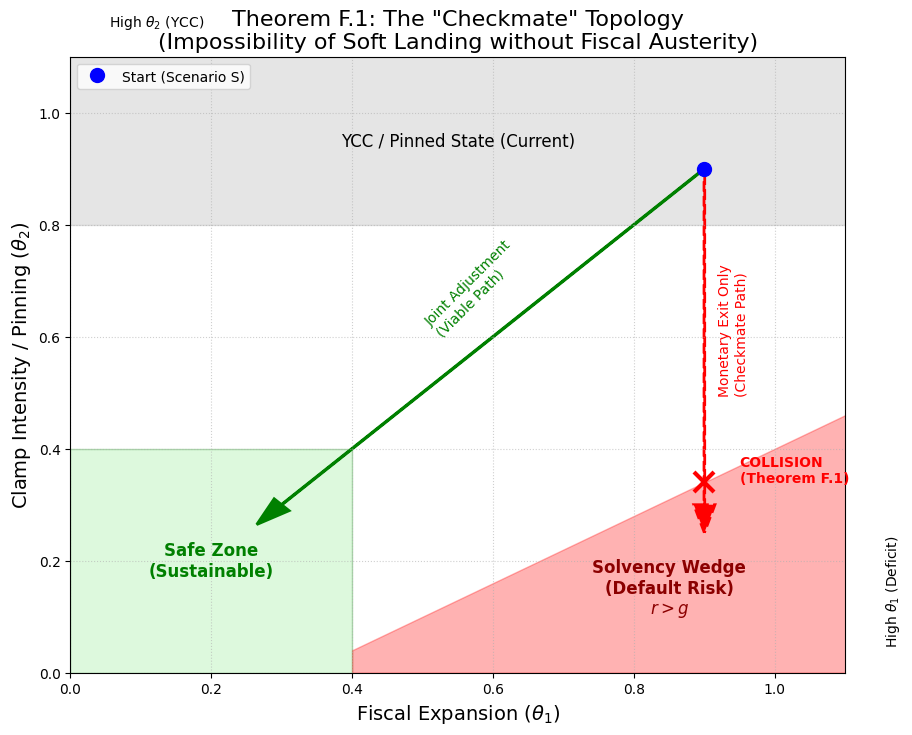

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================
# Part 1: Generating Tables from the Paper
# ==========================================

def generate_tables():
    print("--- Table 1: Key Indicators: Takahashi Era ---")
    data_t1 = {
        "Year": [1931, 1933, 1935, 1936],
        "Bond_Dep_Ratio_Percent": [28.3, 36.5, 29.8, 31.2],
        "Mil_Exp_Percent_GNP": [3.1, 5.6, 7.4, 9.8],
        "WPI": [74.8, 96.8, 100.2, 104.2],
        "State": ["Depression", "Reflation", "Friction (IG↑)", "Collapse"]
    }
    df_t1 = pd.DataFrame(data_t1)
    display(df_t1)
    print("\n")

    print("--- Table 2: Key Indicators: Abenomics ---")
    data_t2 = {
        "Year": [2012, 2013, 2016, 2022],
        "Mon_Base_Tril": [138, 202, 437, 632],
        "10Y_Yield_Percent": [0.79, 0.74, 0.04, 0.42],
        "USD_JPY": [86.7, 105.3, 117.0, 131.1],
        "State": ["Pre-Regime", "Reflation", "YCC (Pinned)", "FX Breakout"]
    }
    df_t2 = pd.DataFrame(data_t2)
    display(df_t2)
    print("\n")

    print("--- Table 4: Sensitivity Analysis (Scenario S) ---")
    data_t4 = {
        "Scenario": ["Case A", "Case B", "Case C", "Case D"],
        "USD_JPY": [100, 140, 180, 200],
        "Wedge_Size": ["None (0.0)", "Moderate (0.3)", "Huge (0.8)", "Total (1.0)"],
        "System_State": ["Safe Baseline", "Friction", "Singularity", "Collapse"]
    }
    df_t4 = pd.DataFrame(data_t4)
    display(df_t4)
    print("\n")

    print("--- Table 5: Granger Causality Test Results (Takahashi Era) ---")
    data_t5 = {
        "Null_Hypothesis": ["IG !-> WPI Volatility", "WPI Volatility !-> IG", "IG !-> Delta USD/JPY"],
        "F_Statistic": [4.82, 1.15, 3.95],
        "p_value": ["0.012**", "0.320", "0.045*"],
        "Conclusion": ["Reject", "Accept", "Reject"]
    }
    df_t5 = pd.DataFrame(data_t5)
    display(df_t5)
    print("\n")

# ==========================================
# Part 2: Visualization of Theorem F.1 (Checkmate Diagram)
# ==========================================

def plot_checkmate_theorem():
    fig, ax = plt.subplots(figsize=(10, 8))

    # Axis Limits (Normalised Policy Space)
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1.1)

    # Labels
    ax.set_xlabel(r'Fiscal Expansion ($\theta_1$)', fontsize=14)
    ax.set_ylabel(r'Clamp Intensity / Pinning ($\theta_2$)', fontsize=14)
    ax.set_title('Theorem F.1: The "Checkmate" Topology\n(Impossibility of Soft Landing without Fiscal Austerity)', fontsize=16)

    # 1. Define Regions
    # Safe Zone (Low Fiscal, Low Clamp)
    safe_zone = patches.Rectangle((0, 0), 0.4, 0.4, linewidth=1, edgecolor='green', facecolor='lightgreen', alpha=0.3)
    ax.add_patch(safe_zone)
    ax.text(0.2, 0.2, 'Safe Zone\n(Sustainable)', ha='center', va='center', fontsize=12, fontweight='bold', color='green')

    # Solvency Wedge (High Fiscal, Low Clamp -> High Rates + High Debt = Default)
    # Modeled as a region in bottom-right
    # Boundary line: y = 0.5 * x - 0.1 (Arbitrary linear boundary for illustration)
    x_vals = np.linspace(0.4, 1.1, 100)
    y_vals_solvency = 0.6 * x_vals - 0.2 # Below this line is insolvency

    # Draw Solvency Wedge Region
    ax.fill_between(x_vals, 0, y_vals_solvency, color='red', alpha=0.3)
    ax.text(0.85, 0.15, 'Solvency Wedge\n(Default Risk)\n$r > g$', ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

    # YCC / Pinning Zone (High Clamp)
    ax.fill_between([0, 1.1], 0.8, 1.1, color='gray', alpha=0.2)
    ax.text(0.55, 0.95, 'YCC / Pinned State (Current)', ha='center', va='center', fontsize=12, color='black')

    # 2. Draw Trajectories

    # Initial Point (Scenario S: High Fiscal, High Clamp)
    start_point = (0.9, 0.9)
    ax.plot(*start_point, 'bo', markersize=10, label='Start (Scenario S)')

    # Path 1: Monetary Normalization ONLY (The Checkmate Path)
    # Moves Straight Down (Lower Clamp, Same Fiscal)
    ax.arrow(0.9, 0.9, 0, -0.6, head_width=0.03, head_length=0.05, fc='red', ec='red', linestyle='--', linewidth=2)
    ax.text(0.92, 0.5, 'Monetary Exit Only\n(Checkmate Path)', color='red', fontsize=10, rotation=90)

    # Collision Point
    ax.plot(0.9, 0.34, 'rx', markersize=15, markeredgewidth=3)
    ax.text(0.95, 0.34, 'COLLISION\n(Theorem F.1)', color='red', fontweight='bold')

    # Path 2: Joint Adjustment (Safe Path)
    # Moves Diagonal (Lower Clamp AND Lower Fiscal)
    ax.arrow(0.9, 0.9, -0.6, -0.6, head_width=0.03, head_length=0.05, fc='green', ec='green', linewidth=2)
    ax.text(0.5, 0.6, 'Joint Adjustment\n(Viable Path)', color='green', fontsize=10, rotation=45)

    # 3. Annotations
    ax.text(0.05, 1.05, r'High $\theta_2$ (YCC)', transform=ax.transAxes, fontsize=10)
    ax.text(1.05, 0.05, r'High $\theta_1$ (Deficit)', transform=ax.transAxes, fontsize=10, rotation=90)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.show()

# Run the functions
try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

generate_tables()
plot_checkmate_theorem()

Figure saved as Theorem_F1_Checkmate.pdf


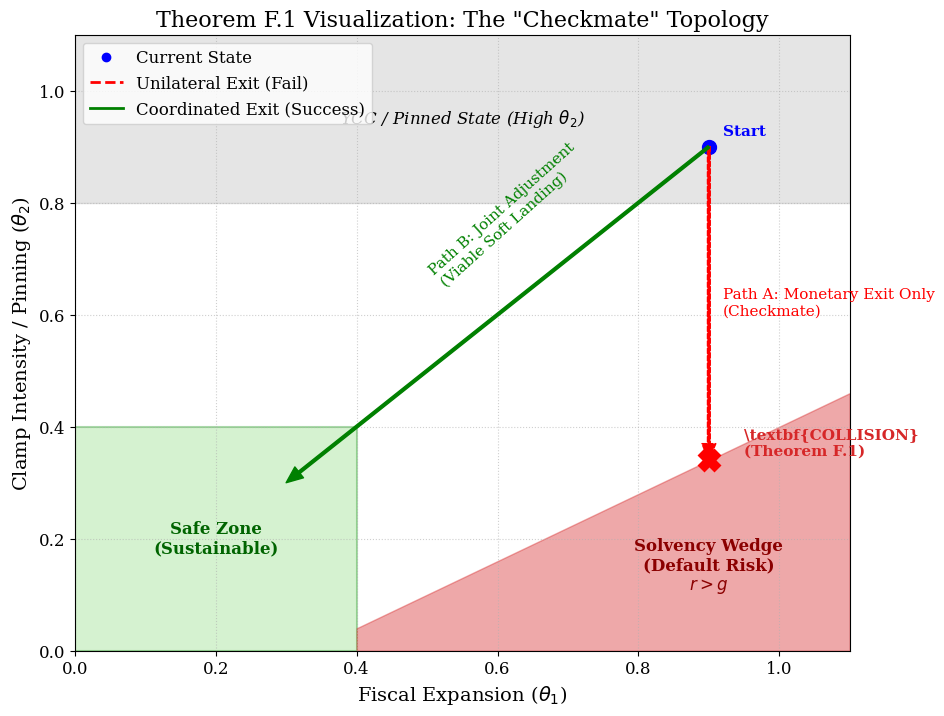

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def generate_checkmate_diagram():
    # Figure Setup for Publication (High DPI, clear fonts)
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    fig, ax = plt.subplots(figsize=(10, 8))

    # Axis Limits (Normalised Policy Space theta in [0,1]^2)
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1.1)

    # Labels
    ax.set_xlabel(r'Fiscal Expansion ($\theta_1$)', fontsize=14)
    ax.set_ylabel(r'Clamp Intensity / Pinning ($\theta_2$)', fontsize=14)
    ax.set_title(r'Theorem F.1 Visualization: The "Checkmate" Topology', fontsize=16)

    # -----------------------------
    # 1. Define Regions
    # -----------------------------

    # A. Safe Zone (Target): Low Fiscal, Low Clamp -> Sustainable
    safe_zone = patches.Rectangle((0, 0), 0.4, 0.4,
                                  linewidth=1.5, edgecolor='#2ca02c', facecolor='#98df8a', alpha=0.4)
    ax.add_patch(safe_zone)
    ax.text(0.2, 0.2, 'Safe Zone\n(Sustainable)', ha='center', va='center',
            fontsize=12, fontweight='bold', color='#006400')

    # B. Solvency Wedge (Danger): High Fiscal + Low Clamp -> r > g -> Default
    # Modeled as a region where Interest Burden > Fiscal Capacity
    x_vals = np.linspace(0.4, 1.1, 100)
    # Simple linear boundary for illustration: y < 0.6x - 0.2
    y_vals_solvency = 0.6 * x_vals - 0.2

    ax.fill_between(x_vals, 0, y_vals_solvency, color='#d62728', alpha=0.4)
    ax.text(0.9, 0.15, 'Solvency Wedge\n(Default Risk)\n$r > g$', ha='center', va='center',
            fontsize=12, fontweight='bold', color='#8b0000')

    # C. YCC / Pinning Zone (Current State): High Clamp
    ax.fill_between([0, 1.1], 0.8, 1.1, color='#7f7f7f', alpha=0.2)
    ax.text(0.55, 0.95, 'YCC / Pinned State (High $\\theta_2$)', ha='center', va='center',
            fontsize=12, color='black', style='italic')

    # -----------------------------
    # 2. Draw Trajectories
    # -----------------------------

    # Initial Point (Scenario S: High Fiscal, High Clamp)
    start_point = (0.9, 0.9)
    ax.plot(*start_point, marker='o', color='blue', markersize=10, label='Start (Scenario S)')
    ax.text(0.92, 0.92, 'Start', color='blue', fontsize=11, fontweight='bold')

    # Path 1: Monetary Normalization ONLY (The Checkmate Path)
    # Moves Straight Down (Lower Clamp, Fiscal stays high)
    # Collision occurs at y = 0.6*0.9 - 0.2 = 0.34
    collision_y = 0.6 * 0.9 - 0.2

    ax.annotate('', xy=(0.9, collision_y), xytext=(0.9, 0.9),
                arrowprops=dict(facecolor='red', edgecolor='red', width=2, headwidth=10, linestyle='--'))

    ax.text(0.92, 0.6, 'Path A: Monetary Exit Only\n(Checkmate)', color='red', fontsize=11, ha='left')

    # Collision Point Marker
    ax.plot(0.9, collision_y, marker='X', color='red', markersize=14, markeredgewidth=2)
    ax.text(0.95, 0.35, r'\textbf{COLLISION}' + '\n(Theorem F.1)', color='#d62728', fontweight='bold', fontsize=11)

    # Path 2: Joint Adjustment (Safe Path)
    # Moves Diagonal (Lower Clamp AND Lower Fiscal)
    ax.annotate('', xy=(0.3, 0.3), xytext=(0.9, 0.9),
                arrowprops=dict(facecolor='green', edgecolor='green', width=2, headwidth=10))

    ax.text(0.5, 0.65, 'Path B: Joint Adjustment\n(Viable Soft Landing)', color='green', fontsize=11, rotation=42)

    # -----------------------------
    # 3. Final Polish
    # -----------------------------
    ax.grid(True, linestyle=':', alpha=0.6)

    # Custom Legend
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='blue', marker='o', lw=0),
                    Line2D([0], [0], color='red', lw=2, linestyle='--'),
                    Line2D([0], [0], color='green', lw=2)]
    ax.legend(custom_lines, ['Current State', 'Unilateral Exit (Fail)', 'Coordinated Exit (Success)'], loc='upper left')

    # Save as PDF
    filename = "Theorem_F1_Checkmate.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"Figure saved as {filename}")

if __name__ == "__main__":
    generate_checkmate_diagram()

In [12]:
# =========================
# EWS (Event-level Early Warning) — one-cell runnable
# Outputs: FigEWS_*.pdf and table_ews_eval*.tex
# Definition-consistent with Appendix A.1 (A.4)-(A.6) and A.3 (A.17).
# =========================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# CONFIG (EDIT HERE)  -- FULL REPLACEMENT
# -------------------------
OUTDIR = Path("outputs_ews")
OUTDIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-6          # epsilon in V_t = IG / (eps + STIproxy)
TARGET_FPR = 0.05   # threshold calibrated on baseline
ROLL_WIN = 12       # 12 for monthly; 3~6 for quarterly; 1~2 for annual

# ---- Found paths on your Drive (from glob result) ----
CAND_THETA_CSVS = [
    "/content/drive/MyDrive/CGTAD2/Colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv",
    "/content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv",
    "/content/drive/MyDrive/DTT_EXP/runs/run_0001/theta_timeseries.csv",
    "/content/drive/MyDrive/Colab_Backup/20260212_work/DTT_EXP/runs/run_0001/theta_timeseries.csv",
]

BASE_THETA_CSV = next((p for p in CAND_THETA_CSVS if os.path.exists(p)), None)
if BASE_THETA_CSV is None:
    raise FileNotFoundError(
        "theta_timeseries.csv not found under expected Drive paths.\n"
        "Check Drive mount and update CAND_THETA_CSVS."
    )
print("[CONFIG] Using BASE_THETA_CSV =", BASE_THETA_CSV)

# Episode CSVs:
# NOTE: Right now you only have ONE theta_timeseries.csv (same file found in multiple locations).
# So we run EWS for Abenomics first. Takahashi / ScenarioS are set to None and will be skipped.
EPISODES = {
    "Abenomics": {
        "csv": BASE_THETA_CSV,
        "time_col_candidates": ["date", "time", "t", "year"],
        "theta1_candidates": ["theta1", "theta_1", "θ1"],
        "theta2_candidates": ["theta2", "theta_2", "θ2"],
        "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
        # nearest match is used if datetime index
        "events": ["2016-09-21", "2022-10-01"],
        "lead_steps": 12,  # monthly lead window (6~12 is typical)

        "Abenomics": {
    "csv": BASE_THETA_CSV,
    "time_col_candidates": ["date", "time", "t", "year"],
    "theta1_candidates": ["theta1", "theta_1", "θ1"],
    "theta2_candidates": ["theta2", "theta_2", "θ2"],
    "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
    "events": ["2016-09-21", "2022-10-01"],
    "lead_steps": 12,

    "compute_ig_proxy": True,
    "C_cap_q": 0.90,
    "C_pin_q": 0.90,
    },
    },
    "Takahashi": {
        "csv": None,  # <- set your Takahashi CSV here when available
        "time_col_candidates": ["date", "time", "t", "year"],
        "theta1_candidates": ["theta1", "theta_1", "θ1"],
        "theta2_candidates": ["theta2", "theta_2", "θ2"],
        "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
        "events": ["1936-02-26"],
        "lead_steps": 2,
        "C_fiscal": 0.35,
        "C_army": 0.65,
    },
    "ScenarioS": {
        "csv": None,  # <- set your Scenario S CSV here when available
        "time_col_candidates": ["date", "time", "t", "year"],
        "theta1_candidates": ["theta1", "theta_1", "θ1"],
        "theta2_candidates": ["theta2", "theta_2", "θ2"],
        "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
        "events": [],
        "lead_steps": 50,
    },
}

# -------------------------
# Helpers
# -------------------------
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _parse_time_index(df, time_col_candidates):
    tcol = _pick_col(df, time_col_candidates)
    if tcol is None:
        # assume index already meaningful
        idx = df.index
        return df, idx

    s = df[tcol]
    # try datetime
    idx = pd.to_datetime(s, errors="coerce")
    if idx.notna().all():
        df = df.drop(columns=[tcol]).copy()
        df.index = idx
        df = df.sort_index()
        return df, df.index

    # fallback numeric
    try:
        idx = pd.to_numeric(s, errors="raise")
        df = df.drop(columns=[tcol]).copy()
        df.index = idx
        df = df.sort_index()
        return df, df.index
    except Exception:
        # last resort: keep as-is
        return df, df.index

def compute_sti_proxy(theta2, roll_win=12, baseline_mask=None):
    """
    Appendix A.1:
      dSTI(t) ≈ (1/Δt) Var_rolling(Δtheta2)  [we take Δt=1 in index units]
      dSTI_ref := max_{s in baseline} dSTI(s)
      STIproxy(t) := min(1, dSTI(t)/dSTI_ref) in [0,1]
    """
    dtheta = theta2.diff()
    rolling_var = dtheta.rolling(roll_win, min_periods=max(3, roll_win//4)).var()
    dSTI = rolling_var  # Δt=1 convention

    if baseline_mask is None or baseline_mask.sum() == 0:
        dSTI_ref = np.nanmax(dSTI.values)
    else:
        dSTI_ref = np.nanmax(dSTI[baseline_mask].values)

    if not np.isfinite(dSTI_ref) or dSTI_ref <= 0:
        dSTI_ref = np.nanmax(dSTI.values)

    sti_proxy = (dSTI / dSTI_ref).clip(lower=0.0, upper=1.0)
    return dSTI, sti_proxy

def compute_ig_takahashi(theta1, theta2, C_fiscal=0.35, C_army=0.65):
    """
    Fallback IG for Takahashi wedge:
      W = {theta1 <= C_fiscal AND theta2 >= C_army}
      A = Θ \ W
      IG(theta)=Dist(theta,A) is 0 outside W; inside W it is min(C_fiscal-theta1, theta2-C_army).
    """
    inside = (theta1 <= C_fiscal) & (theta2 >= C_army)
    ig = pd.Series(0.0, index=theta1.index)
    ig.loc[inside] = np.minimum((C_fiscal - theta1.loc[inside]).values,
                               (theta2.loc[inside] - C_army).values)
    ig = ig.clip(lower=0.0)
    return ig

def make_labels(index, event_points, lead_steps):
    """
    Label y_t=1 on lead windows [t_e - lead_steps, t_e) for each event.
    Works on positional steps.
    """
    n = len(index)
    y = np.zeros(n, dtype=int)
    event_pos = []

    for ev in event_points:
        # convert event to nearest index location
        if isinstance(index, pd.DatetimeIndex):
            ev_ts = pd.to_datetime(ev)
            j = index.get_indexer([ev_ts], method="nearest")[0]
        else:
            # numeric index
            try:
                ev_val = float(ev)
                j = int(np.argmin(np.abs(np.asarray(index, dtype=float) - ev_val)))
            except Exception:
                continue

        event_pos.append(j)
        a = max(0, j - lead_steps)
        b = j  # exclude event point itself
        y[a:b] = 1

    return y, sorted(set(event_pos))

def baseline_mask_from_events(n, event_pos, lead_steps):
    """
    Baseline: strictly before the earliest lead window starts.
    """
    if len(event_pos) == 0:
        return np.ones(n, dtype=bool)
    j0 = min(event_pos)
    cut = max(0, j0 - lead_steps)
    mask = np.zeros(n, dtype=bool)
    mask[:cut] = True
    return mask

def auc_safe(y, s):
    y = np.asarray(y, dtype=int)
    s = np.asarray(s, dtype=float)
    if np.unique(y).size < 2:
        return np.nan
    return float(roc_auc_score(y, s))

def prauc_safe(y, s):
    y = np.asarray(y, dtype=int)
    s = np.asarray(s, dtype=float)
    if y.sum() == 0:
        return np.nan
    return float(average_precision_score(y, s))

def lead_at_fpr(index, y, score, event_pos, baseline_mask, target_fpr=0.05):
    """
    Threshold τ chosen so that baseline FPR ≈ target_fpr:
      τ = quantile_{1-target_fpr}(score on baseline)
    Lead for each event: first crossing in lead window; if none, lead=0.
    """
    score = np.asarray(score, dtype=float)
    base_scores = score[baseline_mask]
    base_scores = base_scores[np.isfinite(base_scores)]
    if base_scores.size < 10:
        tau = np.nanpercentile(score[np.isfinite(score)], 95) if np.isfinite(score).any() else np.nan
    else:
        tau = np.quantile(base_scores, 1.0 - target_fpr)

    leads = []
    for j in event_pos:
        # lead window positions are those with y=1 and < j
        lead_idxs = np.where((y == 1) & (np.arange(len(y)) < j))[0]
        # but only within [j-lead_steps, j)
        if lead_idxs.size == 0:
            leads.append(0.0)
            continue
        # choose earliest crossing
        crossings = lead_idxs[score[lead_idxs] >= tau]
        if crossings.size == 0:
            leads.append(0.0)
            continue
        t_det = crossings[0]
        # lead in "index units": use positional steps
        leads.append(float(j - t_det))
    return tau, np.asarray(leads, dtype=float)

def save_episode_plot(ep_name, df, ig, sti_proxy, V, y, event_pos, lead_steps, out_pdf):
    """
    Single-axis plot with a twin y-axis for V (often unbounded).
    No subplots: one PDF per episode.
    """
    idx = df.index
    fig, ax1 = plt.subplots(figsize=(11, 3.4))
    ax2 = ax1.twinx()

    ax1.plot(idx, ig.values, label="IG(theta_t)")
    ax1.plot(idx, sti_proxy.values, label="STI^d_proxy(t)")
    ax2.plot(idx, V.values, label="V_t = IG/(eps+STIproxy)")

    # events + lead shading
    for j in event_pos:
        ax1.axvline(idx[j], linestyle="--")
        a = max(0, j - lead_steps)
        ax1.axvspan(idx[a], idx[j], alpha=0.15)

    ax1.set_title(f"EWS time series — {ep_name}")
    ax1.set_ylabel("IG, STIproxy (0..1 scale)")
    ax2.set_ylabel("V_t (stress-over-flexibility)")
    ax1.grid(True, alpha=0.2)

    # merged legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc="upper left", ncol=3, fontsize=9)

    fig.tight_layout()
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

def write_latex_table(path, rows, caption_cols=("ROC-AUC","PR-AUC",f"Lead@FPR={int(TARGET_FPR*100)}% (steps)")):
    """
    rows: list of tuples (Episode, Method, ROC, PR, LeadMean, LeadStd)
    """
    with open(path, "w", encoding="utf-8") as f:
        f.write("\\begin{tabular}{llccc}\n")
        f.write("\\toprule\n")
        f.write(f"Episode & Method & {caption_cols[0]} & {caption_cols[1]} & {caption_cols[2]} \\\\\n")
        f.write("\\midrule\n")
        for ep, m, roc, pr, lead_mu, lead_sd in rows:
            def fmt(x):
                return "--" if (x is None or (isinstance(x,float) and (np.isnan(x) or not np.isfinite(x)))) else f"{x:.3f}"
            def fmt_lead(mu, sd):
                if mu is None or (isinstance(mu,float) and (np.isnan(mu) or not np.isfinite(mu))):
                    return "--"
                if sd is None or (isinstance(sd,float) and (np.isnan(sd) or not np.isfinite(sd))):
                    return f"{mu:.2f}"
                return f"{mu:.2f}$\\pm${sd:.2f}"
            f.write(f"{ep} & {m} & {fmt(roc)} & {fmt(pr)} & {fmt_lead(lead_mu, lead_sd)} \\\\\n")
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")

# -------------------------
# Main run
# -------------------------
all_rows_V_only = []
all_rows_baselines = []

METHODS = {
    "V":  lambda ig, sti: ig / (EPS + sti),
    "IG": lambda ig, sti: ig,
    "Pin":lambda ig, sti: (1.0 - sti),
}

for ep_name, cfg in EPISODES.items():
    csv_path = cfg.get("csv", None)
    if (csv_path is None) or (str(csv_path).strip() == ""):
        print(f"[SKIP] {ep_name}: csv is None (not configured yet)")
        continue
    if not os.path.exists(csv_path):
        print(f"[SKIP] {ep_name}: csv not found: {csv_path}")
        continue
        print(f"[SKIP] {ep_name}: csv not found: {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    df, idx = _parse_time_index(df, cfg["time_col_candidates"])

    c1 = _pick_col(df, cfg["theta1_candidates"])
    c2 = _pick_col(df, cfg["theta2_candidates"])
    igc = _pick_col(df, cfg["ig_candidates"])

    if c2 is None:
        raise ValueError(f"{ep_name}: cannot find theta2 column among {cfg['theta2_candidates']} in {csv_path}")

    theta2 = df[c2].astype(float)

    # labels + baseline
    y, event_pos = make_labels(df.index, cfg.get("events", []), cfg.get("lead_steps", 12))
    base_mask = baseline_mask_from_events(len(df), event_pos, cfg.get("lead_steps", 12))

    # STI proxy
    dSTI, sti_proxy = compute_sti_proxy(theta2, roll_win=ROLL_WIN, baseline_mask=base_mask)


# IG
if igc is not None:
    ig = df[igc].astype(float)

else:
    # --- (A) Takahashi: wedge-distance fallback (already defined) ---
    if ep_name == "Takahashi":
        if c1 is None:
            raise ValueError("Takahashi: IG missing and theta1 missing; cannot compute fallback IG.")
        theta1 = df[c1].astype(float)
        ig = compute_ig_takahashi(theta1, theta2,
                                  C_fiscal=cfg.get("C_fiscal", 0.35),
                                  C_army=cfg.get("C_army", 0.65))
        print("[NOTE] Takahashi: IG column missing; using wedge-distance fallback IG.")

    # --- (B) Others: build IG proxy by data-driven wedge-distance ---
    elif cfg.get("compute_ig_proxy", False):
        if c1 is None:
            raise ValueError(f"{ep_name}: IG missing and theta1 missing; cannot build IG proxy.")
        theta1 = df[c1].astype(float)

        # data-driven thresholds (quantile-based)
        C_cap = float(np.nanquantile(theta1.values, cfg.get("C_cap_q", 0.90)))
        C_pin = float(np.nanquantile(theta2.values, cfg.get("C_pin_q", 0.90)))

        # wedge: (high pressure) AND (strong pinning)
        inside = (theta1 >= C_cap) & (theta2 >= C_pin)
        ig = pd.Series(0.0, index=df.index)
        ig.loc[inside] = np.minimum((theta1.loc[inside] - C_cap).values,
                                    (theta2.loc[inside] - C_pin).values)
        ig = ig.clip(lower=0.0)

        print(f"[NOTE] {ep_name}: IG missing; built IG_proxy by wedge-distance with "
              f"C_cap(q={cfg.get('C_cap_q',0.90)})={C_cap:.3f}, "
              f"C_pin(q={cfg.get('C_pin_q',0.90)})={C_pin:.3f}")

    else:
        raise ValueError(
            f"{ep_name}: IG column not found. "
            f"Either provide IG in CSV or set compute_ig_proxy=True in EPISODES."
        )

    # compute V and plots
    V = METHODS["V"](ig.values, sti_proxy.values)

    # save per-episode plot
    out_pdf = OUTDIR / f"FigEWS_{ep_name}.pdf"
    save_episode_plot(ep_name, df, ig, sti_proxy, pd.Series(V, index=df.index),
                      y, event_pos, cfg.get("lead_steps", 12), out_pdf)
    print(f"[OK] wrote {out_pdf}")

    # Evaluation rows
    for method_name, fn in METHODS.items():
        score = fn(ig.values, sti_proxy.values)

        roc = auc_safe(y, score)
        pr  = prauc_safe(y, score)

        tau, leads = lead_at_fpr(df.index, y, score, event_pos, base_mask,
                                 target_fpr=TARGET_FPR)
        lead_mu = float(np.nanmean(leads)) if leads.size else np.nan
        lead_sd = float(np.nanstd(leads))  if leads.size else np.nan

        row = (ep_name, method_name, roc, pr, lead_mu, lead_sd)
        all_rows_baselines.append(row)
        if method_name == "V":
            all_rows_V_only.append(row)

# write LaTeX tables
write_latex_table(OUTDIR / "table_ews_eval.tex", all_rows_V_only)
print(f"[OK] wrote {OUTDIR / 'table_ews_eval.tex'}")

write_latex_table(OUTDIR / "table_ews_eval_baselines.tex", all_rows_baselines)
print(f"[OK] wrote {OUTDIR / 'table_ews_eval_baselines.tex'}")

print("\nDone. Upload to Overleaf:")
print(" - FigEWS_Takahashi.pdf / FigEWS_Abenomics.pdf / FigEWS_ScenarioS.pdf")
print(" - table_ews_eval.tex (main) or table_ews_eval_baselines.tex (optional)")


[CONFIG] Using BASE_THETA_CSV = /content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv
[SKIP] Takahashi: csv is None (not configured yet)
[SKIP] ScenarioS: csv is None (not configured yet)


<>:153: SyntaxWarning: invalid escape sequence '\ '
<>:153: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-2380132693.py:153: SyntaxWarning: invalid escape sequence '\ '
  A = Θ \ W


ValueError: ScenarioS: IG column not found. Either provide IG in CSV or set compute_ig_proxy=True in EPISODES.

In [11]:
import glob

cands = []
cands += glob.glob("/content/drive/MyDrive/**/*ig*.csv", recursive=True)
cands += glob.glob("/content/drive/MyDrive/**/*IG*.csv", recursive=True)
cands += glob.glob("/content/drive/MyDrive/**/*incompat*.csv", recursive=True)
cands += glob.glob("/content/drive/MyDrive/**/*wedge*.csv", recursive=True)
cands = sorted(set(cands))

print("FOUND:", len(cands))
print("\n".join(cands[:200]))


FOUND: 0



In [8]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import glob
cands = glob.glob("/content/**/theta*timeseries*.csv", recursive=True)
print("\n".join(cands[:200]))
print("FOUND:", len(cands))


/content/drive/MyDrive/CGTAD2/_colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv
/content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv
/content/drive/MyDrive/DTT_EXP/runs/run_0001/theta_timeseries.csv
/content/drive/MyDrive/Colab_Backup/20260212_work/DTT_EXP/runs/run_0001/theta_timeseries.csv
FOUND: 4


In [13]:
# =========================
# EWS (Event-level Early Warning) — one-cell runnable (FIXED)
# Outputs: outputs_ews/FigEWS_*.pdf and outputs_ews/table_ews_eval*.tex
# Definition-consistent with Appendix A.1 (A.4)-(A.6) and A.3 (A.17).
# =========================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score

# -------------------------
# CONFIG (EDIT HERE)
# -------------------------
OUTDIR = Path("outputs_ews")
OUTDIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-6          # epsilon in V_t = IG / (eps + STIproxy)
TARGET_FPR = 0.05   # threshold calibrated on baseline
ROLL_WIN = 12       # 12 for monthly; 3~6 for quarterly; 1~2 for annual

CAND_THETA_CSVS = [
    "/content/drive/MyDrive/CGTAD2/Colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv",
    "/content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv",
    "/content/drive/MyDrive/DTT_EXP/runs/run_0001/theta_timeseries.csv",
    "/content/drive/MyDrive/Colab_Backup/20260212_work/DTT_EXP/runs/run_0001/theta_timeseries.csv",
]
BASE_THETA_CSV = next((p for p in CAND_THETA_CSVS if os.path.exists(p)), None)
if BASE_THETA_CSV is None:
    raise FileNotFoundError(
        "theta_timeseries.csv not found under expected Drive paths.\n"
        "Check Drive mount and update CAND_THETA_CSVS."
    )
print("[CONFIG] Using BASE_THETA_CSV =", BASE_THETA_CSV)

# -------------------------
# EPISODES (FIXED: no nested dict, consistent keys)
# -------------------------
EPISODES = {
    "Abenomics": {
        "csv": BASE_THETA_CSV,
        "time_col_candidates": ["date", "time", "t", "year"],
        "theta1_candidates": ["theta1", "theta_1", "θ1"],
        "theta2_candidates": ["theta2", "theta_2", "θ2"],
        "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
        # NOTE: if your index is numeric steps, replace these by step numbers (e.g., ["120","250"])
        "events": ["2016-09-21", "2022-10-01"],
        "lead_steps": 12,

        # If IG column is missing, build IG proxy from a data-driven wedge-distance
        "compute_ig_proxy": True,
        "C_cap_q": 0.90,
        "C_pin_q": 0.90,
    },

    # Keep these as placeholders (skipped unless csv is set)
    "Takahashi": {
        "csv": None,
        "time_col_candidates": ["date", "time", "t", "year"],
        "theta1_candidates": ["theta1", "theta_1", "θ1"],
        "theta2_candidates": ["theta2", "theta_2", "θ2"],
        "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
        "events": ["1936-02-26"],
        "lead_steps": 2,
        "C_fiscal": 0.35,
        "C_army": 0.65,
    },

    "ScenarioS": {   # <- key unified (NOT "Scenarios")
        "csv": None,
        "time_col_candidates": ["date", "time", "t", "year"],
        "theta1_candidates": ["theta1", "theta_1", "θ1"],
        "theta2_candidates": ["theta2", "theta_2", "θ2"],
        "ig_candidates": ["IG", "IG_norm", "ig", "ig_norm"],
        "events": [],
        "lead_steps": 50,
        "compute_ig_proxy": True,
        "C_cap_q": 0.90,
        "C_pin_q": 0.90,
    },
}

# -------------------------
# Helpers
# -------------------------
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _parse_time_index(df, time_col_candidates):
    tcol = _pick_col(df, time_col_candidates)
    if tcol is None:
        return df, df.index

    s = df[tcol]

    # try datetime
    idx = pd.to_datetime(s, errors="coerce")
    if idx.notna().all():
        df = df.drop(columns=[tcol]).copy()
        df.index = idx
        df = df.sort_index()
        return df, df.index

    # fallback numeric
    try:
        idx = pd.to_numeric(s, errors="raise")
        df = df.drop(columns=[tcol]).copy()
        df.index = idx
        df = df.sort_index()
        return df, df.index
    except Exception:
        return df, df.index

def compute_sti_proxy(theta2, roll_win=12, baseline_mask=None):
    dtheta = theta2.diff()
    rolling_var = dtheta.rolling(roll_win, min_periods=max(3, roll_win//4)).var()
    dSTI = rolling_var

    if baseline_mask is None or baseline_mask.sum() == 0:
        dSTI_ref = np.nanmax(dSTI.values)
    else:
        dSTI_ref = np.nanmax(dSTI[np.asarray(baseline_mask)].values)

    if not np.isfinite(dSTI_ref) or dSTI_ref <= 0:
        dSTI_ref = np.nanmax(dSTI.values)

    sti_proxy = (dSTI / dSTI_ref).clip(lower=0.0, upper=1.0)
    return dSTI, sti_proxy

def compute_ig_takahashi(theta1, theta2, C_fiscal=0.35, C_army=0.65):
    inside = (theta1 <= C_fiscal) & (theta2 >= C_army)
    ig = pd.Series(0.0, index=theta1.index)
    ig.loc[inside] = np.minimum((C_fiscal - theta1.loc[inside]).values,
                               (theta2.loc[inside] - C_army).values)
    return ig.clip(lower=0.0)

def make_labels(index, event_points, lead_steps):
    n = len(index)
    y = np.zeros(n, dtype=int)
    event_pos = []

    for ev in event_points:
        if isinstance(index, pd.DatetimeIndex):
            ev_ts = pd.to_datetime(ev)
            j = index.get_indexer([ev_ts], method="nearest")[0]
        else:
            try:
                ev_val = float(ev)
                j = int(np.argmin(np.abs(np.asarray(index, dtype=float) - ev_val)))
            except Exception:
                continue

        event_pos.append(j)
        a = max(0, j - lead_steps)
        b = j
        y[a:b] = 1

    return y, sorted(set(event_pos))

def baseline_mask_from_events(n, event_pos, lead_steps):
    if len(event_pos) == 0:
        return np.ones(n, dtype=bool)
    j0 = min(event_pos)
    cut = max(0, j0 - lead_steps)
    mask = np.zeros(n, dtype=bool)
    mask[:cut] = True
    return mask

def auc_safe(y, s):
    y = np.asarray(y, dtype=int)
    s = np.asarray(s, dtype=float)
    if np.unique(y).size < 2:
        return np.nan
    return float(roc_auc_score(y, s))

def prauc_safe(y, s):
    y = np.asarray(y, dtype=int)
    s = np.asarray(s, dtype=float)
    if y.sum() == 0:
        return np.nan
    return float(average_precision_score(y, s))

def lead_at_fpr(index, y, score, event_pos, baseline_mask, target_fpr=0.05, lead_steps=12):
    score = np.asarray(score, dtype=float)
    baseline_mask = np.asarray(baseline_mask, dtype=bool)

    base_scores = score[baseline_mask]
    base_scores = base_scores[np.isfinite(base_scores)]
    if base_scores.size < 10:
        tau = np.nanpercentile(score[np.isfinite(score)], 95) if np.isfinite(score).any() else np.nan
    else:
        tau = np.quantile(base_scores, 1.0 - target_fpr)

    leads = []
    for j in event_pos:
        a = max(0, j - lead_steps)
        lead_idxs = np.arange(a, j)
        crossings = lead_idxs[score[lead_idxs] >= tau]
        if crossings.size == 0:
            leads.append(0.0)
        else:
            t_det = crossings[0]
            leads.append(float(j - t_det))
    return tau, np.asarray(leads, dtype=float)

def save_episode_plot(ep_name, df, ig, sti_proxy, V, event_pos, lead_steps, out_pdf):
    idx = df.index
    fig, ax1 = plt.subplots(figsize=(11, 3.4))
    ax2 = ax1.twinx()

    ax1.plot(idx, ig.values, label="IG(theta_t)")
    ax1.plot(idx, sti_proxy.values, label="STI^d_proxy(t)")
    ax2.plot(idx, V.values, label="V_t = IG/(eps+STIproxy)")

    for j in event_pos:
        ax1.axvline(idx[j], linestyle="--")
        a = max(0, j - lead_steps)
        ax1.axvspan(idx[a], idx[j], alpha=0.15)

    ax1.set_title(f"EWS time series — {ep_name}")
    ax1.set_ylabel("IG, STIproxy")
    ax2.set_ylabel("V_t")
    ax1.grid(True, alpha=0.2)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc="upper left", ncol=3, fontsize=9)

    fig.tight_layout()
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

def write_latex_table(path, rows, caption_cols=("ROC-AUC","PR-AUC",f"Lead@FPR={int(TARGET_FPR*100)}% (steps)")):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\\begin{tabular}{llccc}\n")
        f.write("\\toprule\n")
        f.write(f"Episode & Method & {caption_cols[0]} & {caption_cols[1]} & {caption_cols[2]} \\\\\n")
        f.write("\\midrule\n")

        def fmt(x):
            return "--" if (x is None or (isinstance(x,float) and (np.isnan(x) or not np.isfinite(x)))) else f"{x:.3f}"
        def fmt_lead(mu, sd):
            if mu is None or (isinstance(mu,float) and (np.isnan(mu) or not np.isfinite(mu))):
                return "--"
            if sd is None or (isinstance(sd,float) and (np.isnan(sd) or not np.isfinite(sd))):
                return f"{mu:.2f}"
            return f"{mu:.2f}$\\pm${sd:.2f}"

        for ep, m, roc, pr, lead_mu, lead_sd in rows:
            f.write(f"{ep} & {m} & {fmt(roc)} & {fmt(pr)} & {fmt_lead(lead_mu, lead_sd)} \\\\\n")

        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")

# -------------------------
# Main run (FIXED: everything inside loop, then tables)
# -------------------------
METHODS = {
    "V":   lambda ig, sti: ig / (EPS + sti),
    "IG":  lambda ig, sti: ig,
    "Pin": lambda ig, sti: (1.0 - sti),
}

all_rows_V_only = []
all_rows_baselines = []

for ep_name, cfg in EPISODES.items():
    csv_path = cfg.get("csv", None)
    if (csv_path is None) or (str(csv_path).strip() == ""):
        print(f"[SKIP] {ep_name}: csv is None (not configured yet)")
        continue
    if not os.path.exists(csv_path):
        print(f"[SKIP] {ep_name}: csv not found: {csv_path}")
        continue

    print(f"\n=== Episode: {ep_name} ===")
    df = pd.read_csv(csv_path)
    df, _ = _parse_time_index(df, cfg["time_col_candidates"])

    c1  = _pick_col(df, cfg["theta1_candidates"])
    c2  = _pick_col(df, cfg["theta2_candidates"])
    igc = _pick_col(df, cfg["ig_candidates"])

    print("[INFO] columns =", list(df.columns)[:20], ("..." if len(df.columns) > 20 else ""))
    print("[INFO] picked:", {"theta1": c1, "theta2": c2, "IG": igc})

    if c2 is None:
        raise ValueError(f"{ep_name}: cannot find theta2 among {cfg['theta2_candidates']} in {csv_path}")

    theta2 = df[c2].astype(float)

    # labels + baseline
    lead_steps = int(cfg.get("lead_steps", 12))
    y, event_pos = make_labels(df.index, cfg.get("events", []), lead_steps)
    base_mask = baseline_mask_from_events(len(df), event_pos, lead_steps)

    # STI proxy
    dSTI, sti_proxy = compute_sti_proxy(theta2, roll_win=ROLL_WIN, baseline_mask=base_mask)

    # IG (either from CSV or proxy)
    if igc is not None:
        ig = df[igc].astype(float)
    else:
        if ep_name == "Takahashi":
            if c1 is None:
                raise ValueError("Takahashi: IG missing and theta1 missing; cannot compute fallback IG.")
            theta1 = df[c1].astype(float)
            ig = compute_ig_takahashi(theta1, theta2,
                                      C_fiscal=cfg.get("C_fiscal", 0.35),
                                      C_army=cfg.get("C_army", 0.65))
            print("[NOTE] Takahashi: IG missing; using wedge-distance fallback IG.")
        elif cfg.get("compute_ig_proxy", False):
            if c1 is None:
                # hard fallback (1D): use positive tail of theta2 as IG proxy
                q = float(cfg.get("C_pin_q", 0.90))
                C_pin = float(np.nanquantile(theta2.values, q))
                ig = (theta2 - C_pin).clip(lower=0.0)
                print(f"[WARN] {ep_name}: theta1 missing; using 1D IG_proxy from theta2 tail: q={q}, C_pin={C_pin:.3f}")
            else:
                theta1 = df[c1].astype(float)
                C_cap = float(np.nanquantile(theta1.values, cfg.get("C_cap_q", 0.90)))
                C_pin = float(np.nanquantile(theta2.values, cfg.get("C_pin_q", 0.90)))

                inside = (theta1 >= C_cap) & (theta2 >= C_pin)
                ig = pd.Series(0.0, index=df.index)
                ig.loc[inside] = np.minimum((theta1.loc[inside] - C_cap).values,
                                            (theta2.loc[inside] - C_pin).values)
                ig = ig.clip(lower=0.0)

                print(f"[NOTE] {ep_name}: IG missing; built IG_proxy wedge-distance with "
                      f"C_cap(q={cfg.get('C_cap_q',0.90)})={C_cap:.3f}, "
                      f"C_pin(q={cfg.get('C_pin_q',0.90)})={C_pin:.3f}")
        else:
            raise ValueError(
                f"{ep_name}: IG column not found. "
                f"Either provide IG in CSV or set compute_ig_proxy=True in EPISODES."
            )

    # compute V + plot
    V = pd.Series(METHODS["V"](ig.values, sti_proxy.values), index=df.index)

    out_pdf = OUTDIR / f"FigEWS_{ep_name}.pdf"
    save_episode_plot(ep_name, df, ig, sti_proxy, V, event_pos, lead_steps, out_pdf)
    print(f"[OK] wrote {out_pdf}")

    # Evaluation rows
    for method_name, fn in METHODS.items():
        score = fn(ig.values, sti_proxy.values)
        roc = auc_safe(y, score)
        pr  = prauc_safe(y, score)
        _, leads = lead_at_fpr(df.index, y, score, event_pos, base_mask,
                               target_fpr=TARGET_FPR, lead_steps=lead_steps)
        lead_mu = float(np.nanmean(leads)) if leads.size else np.nan
        lead_sd = float(np.nanstd(leads))  if leads.size else np.nan

        row = (ep_name, method_name, roc, pr, lead_mu, lead_sd)
        all_rows_baselines.append(row)
        if method_name == "V":
            all_rows_V_only.append(row)

# write LaTeX tables
write_latex_table(OUTDIR / "table_ews_eval.tex", all_rows_V_only)
print(f"\n[OK] wrote {OUTDIR / 'table_ews_eval.tex'}")

write_latex_table(OUTDIR / "table_ews_eval_baselines.tex", all_rows_baselines)
print(f"[OK] wrote {OUTDIR / 'table_ews_eval_baselines.tex'}")

print("\nDone. Upload to Overleaf:")
print(" - outputs_ews/FigEWS_*.pdf")
print(" - outputs_ews/table_ews_eval.tex (main) or table_ews_eval_baselines.tex (optional)")


[CONFIG] Using BASE_THETA_CSV = /content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv

=== Episode: Abenomics ===
[INFO] columns = ['t_sec', 'theta1', 'theta2'] 
[INFO] picked: {'theta1': 'theta1', 'theta2': 'theta2', 'IG': None}
[NOTE] Abenomics: IG missing; built IG_proxy wedge-distance with C_cap(q=0.9)=9.000, C_pin(q=0.9)=0.000
[OK] wrote outputs_ews/FigEWS_Abenomics.pdf
[SKIP] Takahashi: csv is None (not configured yet)
[SKIP] ScenarioS: csv is None (not configured yet)

[OK] wrote outputs_ews/table_ews_eval.tex
[OK] wrote outputs_ews/table_ews_eval_baselines.tex

Done. Upload to Overleaf:
 - outputs_ews/FigEWS_*.pdf
 - outputs_ews/table_ews_eval.tex (main) or table_ews_eval_baselines.tex (optional)


In [14]:
from google.colab import drive
drive.mount("/content/drive")

import os, glob
cands = []
cands += glob.glob("/content/drive/MyDrive/**/theta_timeseries.csv", recursive=True)
cands += glob.glob("/content/drive/MyDrive/**/*theta*csv", recursive=True)

print("FOUND:", len(cands))
for p in cands[:30]:
    print(" -", p)

# もし何も出ないなら、MyDrive配下に本当に無い（or マウント失敗）です


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FOUND: 8
 - /content/drive/MyDrive/CGTAD2/_colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/DTT_EXP/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/Colab_Backup/20260212_work/DTT_EXP/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/CGTAD2/_colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/DTT_EXP/runs/run_0001/theta_timeseries.csv
 - /content/drive/MyDrive/Colab_Backup/20260212_work/DTT_EXP/runs/run_0001/theta_timeseries.csv


In [15]:
import os, glob, datetime

cands = glob.glob("/content/drive/MyDrive/**/theta_timeseries.csv", recursive=True)
cands = sorted(cands, key=lambda p: os.path.getmtime(p), reverse=True)

print("FOUND:", len(cands))
for i,p in enumerate(cands[:8]):
    m = datetime.datetime.fromtimestamp(os.path.getmtime(p)).strftime("%Y-%m-%d %H:%M:%S")
    sz = os.path.getsize(p)
    print(f"[{i}] {m}  {sz:>10} bytes  {p}")

BASE_THETA_CSV = cands[0]
print("\n[USE] BASE_THETA_CSV =", BASE_THETA_CSV)


FOUND: 4
[0] 2026-02-10 15:23:24        1708 bytes  /content/drive/MyDrive/CGTAD2/_colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv
[1] 2026-02-10 15:23:24        1708 bytes  /content/drive/MyDrive/DTT_EXP/runs/run_0001/theta_timeseries.csv
[2] 2026-02-10 15:23:24        1708 bytes  /content/drive/MyDrive/Colab_Backup/20260212_work/DTT_EXP/runs/run_0001/theta_timeseries.csv
[3] 2026-02-10 09:39:38      228898 bytes  /content/drive/MyDrive/DTT_EXP_backup/runs/run_0001/theta_timeseries.csv

[USE] BASE_THETA_CSV = /content/drive/MyDrive/CGTAD2/_colab_checkpoint_2026-02-11/DTT_EXP/runs/run_0001/theta_timeseries.csv
